In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import timm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

d:\Crop Identification Dataset\cropIdentification\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_PATH = "models/crop_identifier_best.pth"
DATASET_PATH = "processed_dataset"
BATCH_SIZE = 32
IMAGE_SIZE = 224
print(torch.cuda.is_available())
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

True


In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [4]:
test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH,"test"),
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = test_dataset.classes
print(class_names)

['BellPepper', 'Chilli', 'Cotton', 'Groundnut', 'Potato', 'Tomato']


In [7]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=False,
    num_classes=len(class_names)
)

# Load the checkpoint dictionary
checkpoint = torch.load(MODEL_PATH, map_location=device)

# Load only the model state dictionary
model.load_state_dict(checkpoint["model"])

model.to(device)
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [8]:
all_preds = []
all_labels = []
all_probs = []

In [9]:
with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        outputs=model(images)
        probs=torch.softmax(outputs,dim=1)
        _,pred=torch.max(outputs,1)
        all_preds.extend(
            pred.cpu().numpy()
        )
        all_labels.extend(
            labels.numpy()
        )
        all_probs.extend(
            probs.cpu().numpy()
        )

In [10]:
accuracy = np.mean(
    np.array(all_preds)==np.array(all_labels)
)

print(f"Test Accuracy : {accuracy*100:.2f}%")

Test Accuracy : 97.78%


In [11]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

  BellPepper       0.99      0.95      0.97       148
      Chilli       0.99      1.00      0.99       220
      Cotton       0.98      0.98      0.98       170
   Groundnut       0.95      1.00      0.98       275
      Potato       0.97      0.97      0.97       154
      Tomato       0.99      0.95      0.97       160

    accuracy                           0.98      1127
   macro avg       0.98      0.97      0.98      1127
weighted avg       0.98      0.98      0.98      1127



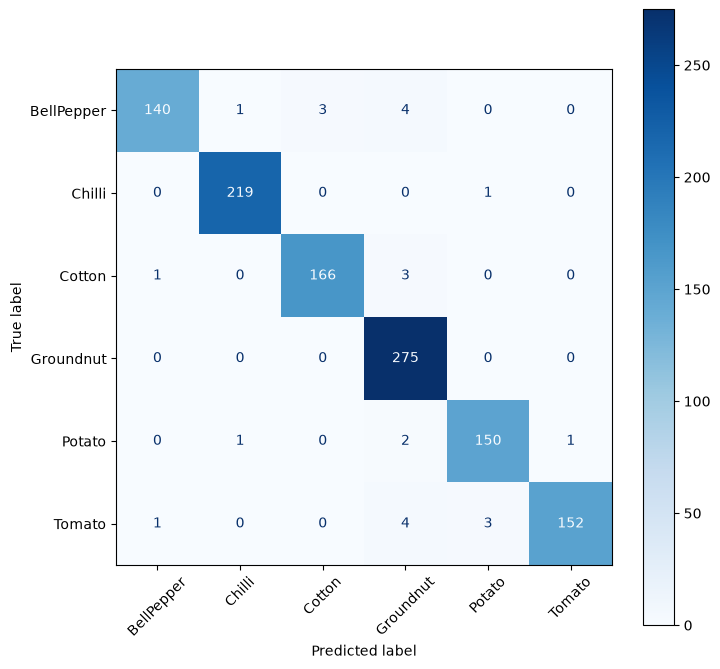

In [12]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig,ax = plt.subplots(
    figsize=(8,8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.show()

In [13]:
wrong = []
model.eval()
index = 0

with torch.no_grad():
    for images,labels in test_loader:
        outputs=model(images.to(device))
        _,pred=torch.max(outputs,1)
        for i in range(len(labels)):
            if pred[i]!=labels[i]:
                wrong.append(
                    (
                        images[i],
                        labels[i],
                        pred[i]
                    )
                )

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0039215386..1.0137256].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015686303..1.0090702].


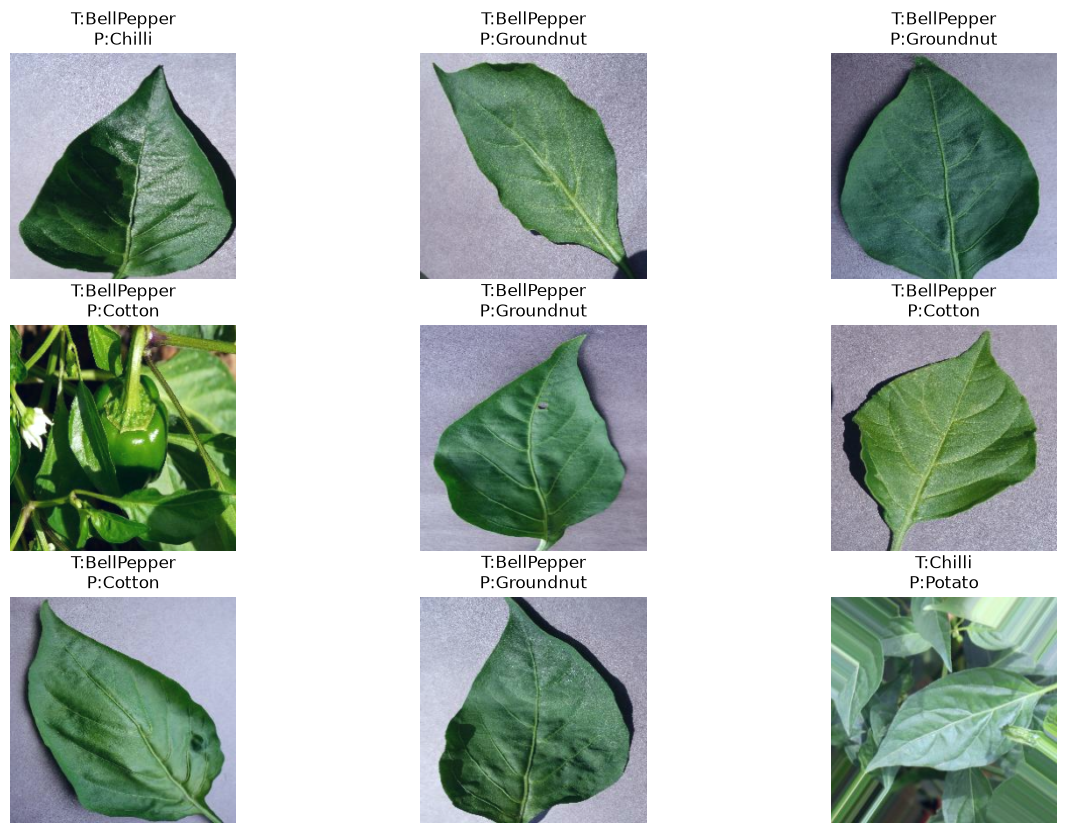

In [14]:
plt.figure(figsize=(15,10))

for i in range(min(9,len(wrong))):
    img,label,pred=wrong[i]
    img=img.permute(1,2,0)
    img=(img*0.229)+0.485
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(
        f"T:{class_names[label]}\nP:{class_names[pred]}"
    )
    plt.axis("off")

plt.show()

In [15]:
confidences = np.max(
    np.array(all_probs),
    axis=1
)

print(
    "Average Confidence:",
    confidences.mean()
)

Average Confidence: 0.8580342


In [16]:
correct = np.zeros(len(class_names))
total = np.zeros(len(class_names))
for p,l in zip(all_preds,all_labels):
    total[l]+=1
    if p==l:
        correct[l]+=1

for i,c in enumerate(class_names):
    print(
        f"{c:15}",
        f"{100*correct[i]/total[i]:.2f}%"
    )

BellPepper      94.59%
Chilli          99.55%
Cotton          97.65%
Groundnut       100.00%
Potato          97.40%
Tomato          95.00%


In [17]:
metrics = {
    "accuracy":float(accuracy),
    "confidence":float(confidences.mean())
}

with open(
    "evaluation.json",
    "w"
) as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

In [18]:
top3_correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        # Get the top 3 predicted class indices
        top3 = torch.topk(outputs, 3).indices

        for i in range(len(labels)):
            # Check if the true label is within the top 3 predictions for each image
            if labels[i] in top3[i]:
                top3_correct += 1
            total += 1

print("Top-3 Accuracy:", top3_correct / total)

Top-3 Accuracy: 0.9991126885536823
